In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

df = pd.read_csv("PS4_GamesSales.csv", encoding="latin1")

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (1034, 9)


,Game,Year,Genre,Publisher,North America,Europe,Japan,Rest of World,Global
0,Grand Theft Auto V,2014.0,Action,Rockstar Games,6.06,9.71,0.60,3.02,19.39
1,Call of Duty: Black Ops 3,2015.0,Shooter,Activision,6.18,6.05,0.41,2.44,15.09
2,Red Dead Redemption 2,2018.0,Action-Adventure,Rockstar Games,5.26,6.21,0.21,2.26,13.94
3,Call of Duty: WWII,2017.0,Shooter,Activision,4.67,6.21,0.40,2.12,13.40
4,FIFA 18,2017.0,Sports,EA Sports,1.27,8.64,0.15,1.73,11.80


In [2]:
display(df.dtypes)

print("\nMissing values:")
display(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())


,0
Game,object
Year,float64
Genre,object
Publisher,object
North America,float64
Europe,float64
Japan,float64
Rest of World,float64
Global,float64



Missing values:


,0
Game,0
Year,209
Genre,0
Publisher,209
North America,0
Europe,0
Japan,0
Rest of World,0
Global,0



Duplicate rows: 0


Task 1 – Data Quality Issues

After checking the dataset, I found that the Year and Publisher columns contain missing values. There are 209 missing values in each of these columns. I also noticed that Year was stored as a float, so I changed it to an integer type to make the data type more appropriate.

In [11]:

numeric_cols = df.select_dtypes(include=np.number).columns

negative_counts = (df[numeric_cols] < 0).sum().sort_values(ascending=False)
print("Negative values by numeric column:")
display(negative_counts[negative_counts > 0])


if "Year" in df.columns:
    print("Year range:")
    display(df["Year"].describe())


Negative values by numeric column:


,0


Year range:


,Year
count,825.000000
mean,2015.966061
std,1.298360
min,2013.000000
25%,2015.000000
50%,2016.000000
75%,2017.000000
max,2020.000000




**Strategy: median imputation for numerical columns.**

Median imputation is appropriate here because sales data can be skewed by a small number of very successful games. The median is less affected by extreme values than the mean.

Only numerical columns with missing values are imputed. The original dataset is left unchanged, and a cleaned copy is created.


In [4]:

df_clean = df.copy()

numeric_missing = [c for c in numeric_cols if df_clean[c].isna().any()]

for col in numeric_missing:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print("Numerical columns imputed:", numeric_missing)
print("\nMissing values after median imputation:")
display(df_clean.isna().sum())


Numerical columns imputed: ['Year']

Missing values after median imputation:


,0
Game,0
Year,0
Genre,0
Publisher,209
North America,0
Europe,0
Japan,0
Rest of World,0
Global,0


## Task 3 — Detect and handle outliers using IQR



In [5]:

if "Global" not in df_clean.columns:
    raise KeyError("The dataset must contain a 'Global' column for the required IQR analysis.")

Q1 = df_clean["Global"].quantile(0.25)
Q3 = df_clean["Global"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = (
    (df_clean["Global"] < lower_bound) |
    (df_clean["Global"] > upper_bound)
)

outliers = df_clean.loc[outlier_mask]

print(f"Q1 = {Q1:.4f}")
print(f"Q3 = {Q3:.4f}")
print(f"IQR = {IQR:.4f}")
print(f"Lower bound = {lower_bound:.4f}")
print(f"Upper bound = {upper_bound:.4f}")
print("Number of outliers:", len(outliers))

display(outliers.head())


Q1 = 0.0000
Q3 = 0.3575
IQR = 0.3575
Lower bound = -0.5363
Upper bound = 0.8938
Number of outliers: 150


,Game,Year,Genre,Publisher,North America,Europe,Japan,Rest of World,Global
0,Grand Theft Auto V,2014.0,Action,Rockstar Games,6.06,9.71,0.60,3.02,19.39
1,Call of Duty: Black Ops 3,2015.0,Shooter,Activision,6.18,6.05,0.41,2.44,15.09
2,Red Dead Redemption 2,2018.0,Action-Adventure,Rockstar Games,5.26,6.21,0.21,2.26,13.94
3,Call of Duty: WWII,2017.0,Shooter,Activision,4.67,6.21,0.40,2.12,13.40
4,FIFA 18,2017.0,Sports,EA Sports,1.27,8.64,0.15,1.73,11.80


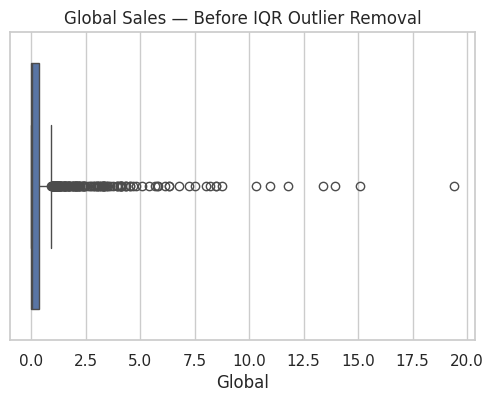

Shape before outlier removal: (1034, 9)
Shape after outlier removal: (884, 9)


In [6]:

plt.figure(figsize=(6, 4))
sns.boxplot(x=df_clean["Global"])
plt.title("Global Sales — Before IQR Outlier Removal")
plt.show()


df_no_outliers = df_clean.loc[~outlier_mask].copy()

print("Shape before outlier removal:", df_clean.shape)
print("Shape after outlier removal:", df_no_outliers.shape)


## Task 4 — Normalize numerical features



In [7]:
regional_features = ["North America", "Europe", "Japan", "Rest of World"]

missing_features = [c for c in regional_features if c not in df_no_outliers.columns]
if missing_features:
    raise KeyError(f"Missing required regional columns: {missing_features}")

X = df_no_outliers[regional_features].copy()


minmax_scaler = MinMaxScaler()
X_minmax = pd.DataFrame(
    minmax_scaler.fit_transform(X),
    columns=regional_features,
    index=X.index
)

print("Min-Max scaled features:")
display(X_minmax.head())
print("\nMin-Max ranges:")
display(X_minmax.agg(["min", "max"]))


Min-Max scaled features:


,North America,Europe,Japan,Rest of World
150,0.559322,0.455882,0.307692,0.866667
151,0.677966,0.485294,0.051282,1.000000
152,0.711864,0.470588,0.000000,1.000000
153,0.118644,1.000000,0.000000,0.866667
154,0.525424,0.617647,0.000000,0.933333



Min-Max ranges:


,North America,Europe,Japan,Rest of World
min,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0


In [8]:

z_scaler = StandardScaler()
X_zscore = pd.DataFrame(
    z_scaler.fit_transform(X),
    columns=regional_features,
    index=X.index
)

print("Z-score standardized features:")
display(X_zscore.head())
print("\nMeans and standard deviations:")
display(pd.DataFrame({
    "mean": X_zscore.mean(),
    "std": X_zscore.std(ddof=0)
}))


Z-score standardized features:


,North America,Europe,Japan,Rest of World
150,3.684578,2.742090,2.608994,3.661938
151,4.593965,2.949368,0.091144,4.317896
152,4.853790,2.845729,-0.412426,4.317896
153,0.306852,6.576726,-0.412426,3.661938
154,3.424753,3.882117,-0.412426,3.989917



Means and standard deviations:


,mean,std
North America,0.000000e+00,1.0
Europe,-1.286050e-16,1.0
Japan,0.000000e+00,1.0
Rest of World,0.000000e+00,1.0


## Task 5 — PCA and explained variance


In [9]:

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_zscore)

pca_df = pd.DataFrame(
    principal_components,
    columns=["PC1", "PC2"],
    index=X_zscore.index
)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()

print("Explained variance ratio:")
for i, value in enumerate(explained_variance, start=1):
    print(f"PC{i}: {value:.4%}")

print(f"\nCumulative explained variance (PC1 + PC2): {cumulative_variance[-1]:.4%}")

display(pca_df.head())


Explained variance ratio:
PC1: 67.1543%
PC2: 22.8602%

Cumulative explained variance (PC1 + PC2): 90.0145%


,PC1,PC2
150,6.269993,1.273598
151,6.719096,-1.397365
152,6.694016,-1.902049
153,5.828937,-1.836331
154,6.275213,-1.846061


PCA loadings:


,PC1,PC2
North America,0.544772,-0.106796
Europe,0.538270,-0.136664
Japan,0.220108,0.975236
Rest of World,0.604187,-0.137234


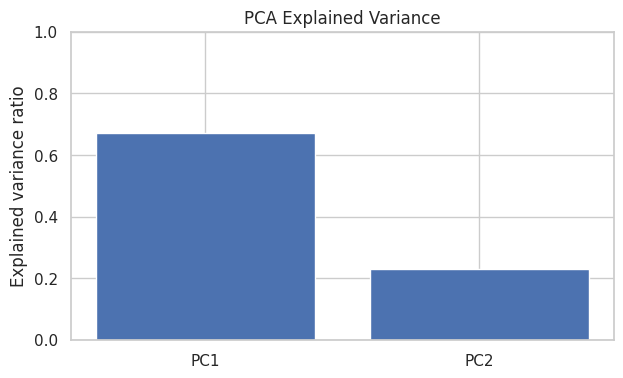

In [10]:

loadings = pd.DataFrame(
    pca.components_.T,
    index=regional_features,
    columns=["PC1", "PC2"]
)

print("PCA loadings:")
display(loadings)

plt.figure(figsize=(7, 4))
plt.bar(["PC1", "PC2"], explained_variance)
plt.ylabel("Explained variance ratio")
plt.title("PCA Explained Variance")
plt.ylim(0, 1)
plt.show()


### PCA interpretation

- **PC1** explains the largest share of the variation in the four regional sales variables.
- **PC2** explains the next largest share.
- The **cumulative explained variance** shown above indicates how much information is retained by using two components instead of the original four variables.
- The PCA loading table shows which regional sales variables contribute most strongly to each component. Larger absolute loading values indicate a stronger contribution.

